In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_final_data
from src.data.clean_data import basic_clean
from src.data.feature_engineering import (
    add_all_labels,
    build_regression_datasets,
    build_quantile_classification_datasets,
    build_binary_classification_datasets,
)
from src.utils.config import PROCESSED_DATA_DIR

pd.set_option("display.max_columns", 200)

In [3]:
df = load_final_data()
print("Raw shape:", df.shape)
df.head()

Raw shape: (5651, 58)


,draft_year,round,pick,team,hof,position,category,side,college,age,to,allpro,probowls,seasons_started,dr_av,player,pos_nfl,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pos_college,G,avg_team_sp,qb_Cmp,qb_Att,qb_Cmp%,qb_Yds,qb_TD,qb_Int,qb_Y/A,qb_AY/A,qb_Y/G,rb_rush_Att,rb_rush_Yds,rb_rush_Y_per_Att,rb_rush_TD,rb_rec_Rec,rb_rec_Yds,rb_rec_Y_per_Rec,rb_rec_TD,rec_Rec,rec_Yds,rec_Y/R,rec_TD,rec_Y/G,Sk,Solo,Ast,Comb,TFL,Int,PD
0,2000,1,1,CLE,False,DE,DL,D,Penn St.,22.0,2005.0,0,0,4,21.0,Courtney Brown,DE,Penn State,77.0,269.0,4.78,NaN,NaN,NaN,NaN,NaN,DL,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000,1,2,WAS,False,LB,LB,D,Penn St.,22.0,2006.0,0,3,5,45.0,LaVar Arrington,OLB,Penn State,75.0,250.0,4.53,NaN,NaN,NaN,NaN,NaN,LB,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000,1,3,WAS,False,T,OL,O,Alabama,23.0,2009.0,0,6,9,63.0,Chris Samuels,OT,Alabama,77.0,325.0,5.08,NaN,NaN,NaN,NaN,NaN,OL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000,1,4,CIN,False,WR,WR,O,Florida St.,23.0,2005.0,0,0,4,25.0,Peter Warrick,WR,Florida State,71.0,194.0,4.58,NaN,NaN,NaN,NaN,NaN,WR,54.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,3517.0,17.0,32.0,65.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000,1,5,BAL,False,RB,RB,O,Tennessee,21.0,2009.0,1,1,9,53.0,Jamal Lewis,RB,Tennessee,72.0,240.0,4.58,23.0,NaN,NaN,NaN,NaN,RB,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,487.0,2677.0,5.5,17.0,39.0,475.0,12.2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Top NFL positions:")
print(df["pos_nfl"].value_counts().head(15))

Top NFL positions:
pos_nfl
WR      647
CB      553
RB      403
DT      370
OT      367
S       344
DE      336
OLB     282
TE      280
QB      211
OG      201
ILB     163
LB      129
C       115
EDGE     96
Name: count, dtype: int64


In [5]:
pos_av = (
    df.groupby("pos_nfl")["dr_av"]
    .agg(["count", "mean", "median", "std"])
    .sort_values(by="count", ascending=False)
)

pos_av.head(15)

,count,mean,median,std
pos_nfl,,,,
WR,647,12.771252,6.0,17.412681
CB,553,11.179024,7.0,13.387973
RB,403,14.498759,8.0,17.537504
DT,370,14.305405,7.0,18.720776
OT,367,19.144414,12.0,20.328003
S,344,13.302326,10.0,14.386639
DE,336,16.598214,10.0,20.487693
OLB,282,16.737589,9.0,20.171205
TE,280,9.021429,4.0,12.965058


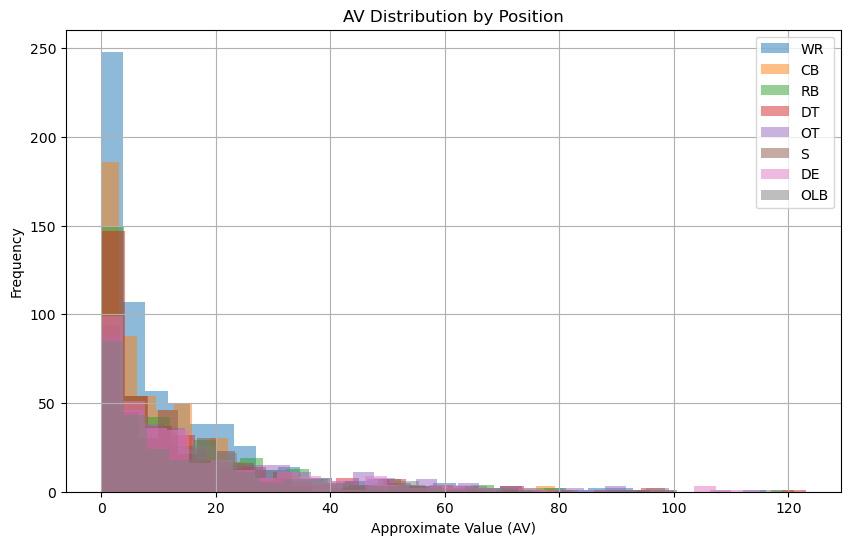

In [6]:
top_positions = df["pos_nfl"].value_counts().head(8).index

plt.figure(figsize=(10, 6))
for pos in top_positions:
    df[df["pos_nfl"] == pos]["dr_av"].hist(alpha=0.5, bins=30, label=pos)

plt.legend()
plt.title("AV Distribution by Position")
plt.xlabel("Approximate Value (AV)")
plt.ylabel("Frequency")
plt.show()

In [7]:
df = basic_clean(df)
df = add_all_labels(df)

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (5651, 63)


,draft_year,round,pick,team,hof,position,category,side,college,age,to,allpro,probowls,seasons_started,dr_av,player,pos_nfl,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pos_college,G,avg_team_sp,qb_Cmp,qb_Att,qb_Cmp%,qb_Yds,qb_TD,qb_Int,qb_Y/A,qb_AY/A,qb_Y/G,rb_rush_Att,rb_rush_Yds,rb_rush_Y_per_Att,rb_rush_TD,rb_rec_Rec,rb_rec_Yds,rb_rec_Y_per_Rec,rb_rec_TD,rec_Rec,rec_Yds,rec_Y/R,rec_TD,rec_Y/G,Sk,Solo,Ast,Comb,TFL,Int,PD,pos_group,pos_fine,av_class,av_class_q,star
0,2000,1,1,CLE,False,DE,DL,D,Penn St.,22.0,2005.0,0,0,4,21.0,Courtney Brown,DE,Penn State,77.0,269.0,4.78,NaN,NaN,NaN,NaN,NaN,DL,12.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEFENSE,DL,2,2,1
1,2000,1,2,WAS,False,LB,LB,D,Penn St.,22.0,2006.0,0,3,5,45.0,LaVar Arrington,OLB,Penn State,75.0,250.0,4.53,NaN,NaN,NaN,NaN,NaN,LB,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DEFENSE,LB,2,2,1
2,2000,1,3,WAS,False,T,OL,O,Alabama,23.0,2009.0,0,6,9,63.0,Chris Samuels,OT,Alabama,77.0,325.0,5.08,NaN,NaN,NaN,NaN,NaN,OL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,OL,OL,2,2,1
3,2000,1,4,CIN,False,WR,WR,O,Florida St.,23.0,2005.0,0,0,4,25.0,Peter Warrick,WR,Florida State,71.0,194.0,4.58,NaN,NaN,NaN,NaN,NaN,WR,54.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,3517.0,17.0,32.0,65.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKILL,WR,2,2,1
4,2000,1,5,BAL,False,RB,RB,O,Tennessee,21.0,2009.0,1,1,9,53.0,Jamal Lewis,RB,Tennessee,72.0,240.0,4.58,23.0,NaN,NaN,NaN,NaN,RB,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,487.0,2677.0,5.5,17.0,39.0,475.0,12.2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SKILL,RB,2,2,1


In [8]:
print("pos_group counts:")
print(df["pos_group"].value_counts())
print()

print("pos_fine counts:")
print(df["pos_fine"].value_counts())
print()

print("Fixed AV class distribution:")
print(df["av_class"].value_counts(normalize=True))
print()

print("Quantile AV class distribution:")
print(df["av_class_q"].value_counts())
print()

print("Binary star distribution:")
print(df["star"].value_counts())

pos_group counts:
pos_group
DEFENSE    2314
SKILL      1330
OTHER      1113
OL          683
QB          211
Name: count, dtype: int64

pos_fine counts:
pos_fine
OTHER    1154
DB        897
DL        802
OL        683
WR        647
LB        574
RB        403
TE        280
QB        211
Name: count, dtype: int64

Fixed AV class distribution:
av_class
0    0.416210
2    0.296054
1    0.287737
Name: proportion, dtype: float64

Quantile AV class distribution:
av_class_q
0    2019
1    1833
2    1799
Name: count, dtype: int64

Binary star distribution:
star
0    3894
1    1757
Name: count, dtype: int64


In [9]:
print(
    df.groupby("pos_group")["dr_av"]
    .agg(["count", "mean", "median", "std"])
)

           count       mean  median        std
pos_group                                     
DEFENSE     2314  13.490925     8.0  16.798574
OL           683  18.380673    12.0  19.859220
OTHER       1113   7.873315     3.0  11.978441
QB           211  19.905213     6.0  31.503145
SKILL       1330  12.505263     6.0  16.718185


In [10]:
reg_datasets = build_regression_datasets(df)
q_datasets = build_quantile_classification_datasets(df)
bin_datasets = build_binary_classification_datasets(df)

print("Regression datasets:")
for pos, data in reg_datasets.items():
    print(f"{pos}: {data.shape}")

print("\nQuantile classification datasets:")
for pos, data in q_datasets.items():
    print(f"{pos}: {data.shape}")

print("\nBinary classification datasets:")
for pos, data in bin_datasets.items():
    print(f"{pos}: {data.shape}")

Regression datasets:
DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)

Quantile classification datasets:
DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)

Binary classification datasets:
DL: (802, 14)
LB: (574, 15)
OL: (683, 11)
WR: (647, 16)
RB: (403, 19)
TE: (280, 16)
DB: (897, 14)
QB: (211, 20)


In [11]:
# Save the master cleaned dataframe with labels
master_path = PROCESSED_DATA_DIR / "final_cleaned_player_data.csv"
df.to_csv(master_path, index=False)
print("Saved:", master_path)

Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\final_cleaned_player_data.csv


In [12]:
# Save regression datasets
for pos, data in reg_datasets.items():
    path = PROCESSED_DATA_DIR / f"{pos.lower()}_regression_data.csv"
    data.to_csv(path, index=False)
    print("Saved:", path)

Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\dl_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\lb_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\ol_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\wr_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\rb_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\te_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\db_regression_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\qb_regression_data.csv


In [13]:
# Save quantile classification datasets
for pos, data in q_datasets.items():
    path = PROCESSED_DATA_DIR / f"{pos.lower()}_quantile_data.csv"
    data.to_csv(path, index=False)
    print("Saved:", path)

Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\dl_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\lb_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\ol_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\wr_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\rb_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\te_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\db_quantile_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\qb_quantile_data.csv


In [14]:
# Save binary classification datasets
for pos, data in bin_datasets.items():
    path = PROCESSED_DATA_DIR / f"{pos.lower()}_binary_data.csv"
    data.to_csv(path, index=False)
    print("Saved:", path)

Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\dl_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\lb_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\ol_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\wr_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\rb_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\te_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\db_binary_data.csv
Saved: D:\School\UCLA\0 PIC 16B\Code\nfl-model\data\processed\qb_binary_data.csv


In [15]:
# Quick check
sample_pos = "QB"

print("Sample regression dataset:")
display(reg_datasets[sample_pos].head())

print("Sample quantile dataset:")
display(q_datasets[sample_pos].head())

print("Sample binary dataset:")
display(bin_datasets[sample_pos].head())

Sample regression dataset:


,qb_Cmp,qb_Att,qb_Cmp%,qb_Yds,qb_TD,qb_Int,qb_Y/A,qb_AY/A,qb_Y/G,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,age,dr_av,draft_year
17,807.0,1265.0,63.8,10698.0,100.0,30.0,8.5,8.97,297.2,75.0,229.0,4.81,22.0,33.5,111.0,7.12,4.16,24.0,41.0,2000
72,1031.0,1679.0,61.4,12541.0,84.0,51.0,7.5,7.10,291.7,75.0,222.0,5.37,22.0,26.5,98.0,7.80,4.78,23.0,3.0,2000
145,326.0,588.0,55.4,4592.0,32.0,16.0,7.8,7.67,120.8,74.0,227.0,4.58,22.0,34.5,113.0,7.09,4.28,22.0,0.0,2000
160,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-45.00,0.0,75.0,229.0,4.91,22.0,34.0,108.0,7.71,4.59,22.0,0.0,2000
173,395.0,638.0,61.9,4773.0,30.0,17.0,7.5,7.22,164.6,76.0,211.0,5.28,22.0,24.5,99.0,7.20,4.38,23.0,168.0,2000


Sample quantile dataset:


,qb_Cmp,qb_Att,qb_Cmp%,qb_Yds,qb_TD,qb_Int,qb_Y/A,qb_AY/A,qb_Y/G,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,age,av_class_q,draft_year
17,807.0,1265.0,63.8,10698.0,100.0,30.0,8.5,8.97,297.2,75.0,229.0,4.81,22.0,33.5,111.0,7.12,4.16,24.0,2,2000
72,1031.0,1679.0,61.4,12541.0,84.0,51.0,7.5,7.10,291.7,75.0,222.0,5.37,22.0,26.5,98.0,7.80,4.78,23.0,1,2000
145,326.0,588.0,55.4,4592.0,32.0,16.0,7.8,7.67,120.8,74.0,227.0,4.58,22.0,34.5,113.0,7.09,4.28,22.0,0,2000
160,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-45.00,0.0,75.0,229.0,4.91,22.0,34.0,108.0,7.71,4.59,22.0,0,2000
173,395.0,638.0,61.9,4773.0,30.0,17.0,7.5,7.22,164.6,76.0,211.0,5.28,22.0,24.5,99.0,7.20,4.38,23.0,2,2000


Sample binary dataset:


,qb_Cmp,qb_Att,qb_Cmp%,qb_Yds,qb_TD,qb_Int,qb_Y/A,qb_AY/A,qb_Y/G,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,age,star,draft_year
17,807.0,1265.0,63.8,10698.0,100.0,30.0,8.5,8.97,297.2,75.0,229.0,4.81,22.0,33.5,111.0,7.12,4.16,24.0,1,2000
72,1031.0,1679.0,61.4,12541.0,84.0,51.0,7.5,7.10,291.7,75.0,222.0,5.37,22.0,26.5,98.0,7.80,4.78,23.0,0,2000
145,326.0,588.0,55.4,4592.0,32.0,16.0,7.8,7.67,120.8,74.0,227.0,4.58,22.0,34.5,113.0,7.09,4.28,22.0,0,2000
160,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-45.00,0.0,75.0,229.0,4.91,22.0,34.0,108.0,7.71,4.59,22.0,0,2000
173,395.0,638.0,61.9,4773.0,30.0,17.0,7.5,7.22,164.6,76.0,211.0,5.28,22.0,24.5,99.0,7.20,4.38,23.0,1,2000
